In [1]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("customer_acquisition_data.csv")

# Display the first 5 rows to make sure it loaded correctly
df.head()

,customer_id,channel,cost,conversion_rate,revenue
0,1,referral,8.320327,0.123145,4199
1,2,paid advertising,30.450327,0.016341,3410
2,3,email marketing,5.246263,0.043822,3164
3,4,social media,9.546326,0.167592,1520
4,5,referral,8.320327,0.123145,2419


In [6]:
import pandas as pd
import numpy as np

# 1. Load the dataset
df = pd.read_csv("customer_acquisition_data.csv")
print("--- Initial Data Check ---")
print(df.info())

# 2. Check for missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. Handle outliers using IQR (Interquartile Range) for Revenue
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
df_cleaned = df[(df['revenue'] >= lower_bound) & (df['revenue'] <= upper_bound)].copy()

print(f"\nOriginal rows: {len(df)}, Cleaned rows (after IQR): {len(df_cleaned)}")

# 4. Save the cleaned dataset locally
df_cleaned.to_csv("cleaned_customer_acquisition_data.csv", index=False)
print("\nCleaned dataset saved successfully!")

--- Initial Data Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      800 non-null    int64  
 1   channel          800 non-null    object 
 2   cost             800 non-null    float64
 3   conversion_rate  800 non-null    float64
 4   revenue          800 non-null    int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 31.4+ KB
None

--- Missing Values ---
customer_id        0
channel            0
cost               0
conversion_rate    0
revenue            0
dtype: int64

Original rows: 800, Cleaned rows (after IQR): 800

Cleaned dataset saved successfully!


--- Cleaned Statistical Summary ---


,customer_id,cost,conversion_rate,revenue
count,800.0000,800.000000,800.000000,800.000000
mean,400.5000,13.148052,0.086305,2769.151250
std,231.0844,9.922337,0.059611,1259.543706
min,1.0000,5.246263,0.016341,500.000000
25%,200.7500,5.246263,0.043822,1694.000000
50%,400.5000,8.320327,0.043822,2764.000000
75%,600.2500,9.546326,0.123145,3824.250000
max,800.0000,30.450327,0.167592,4998.000000


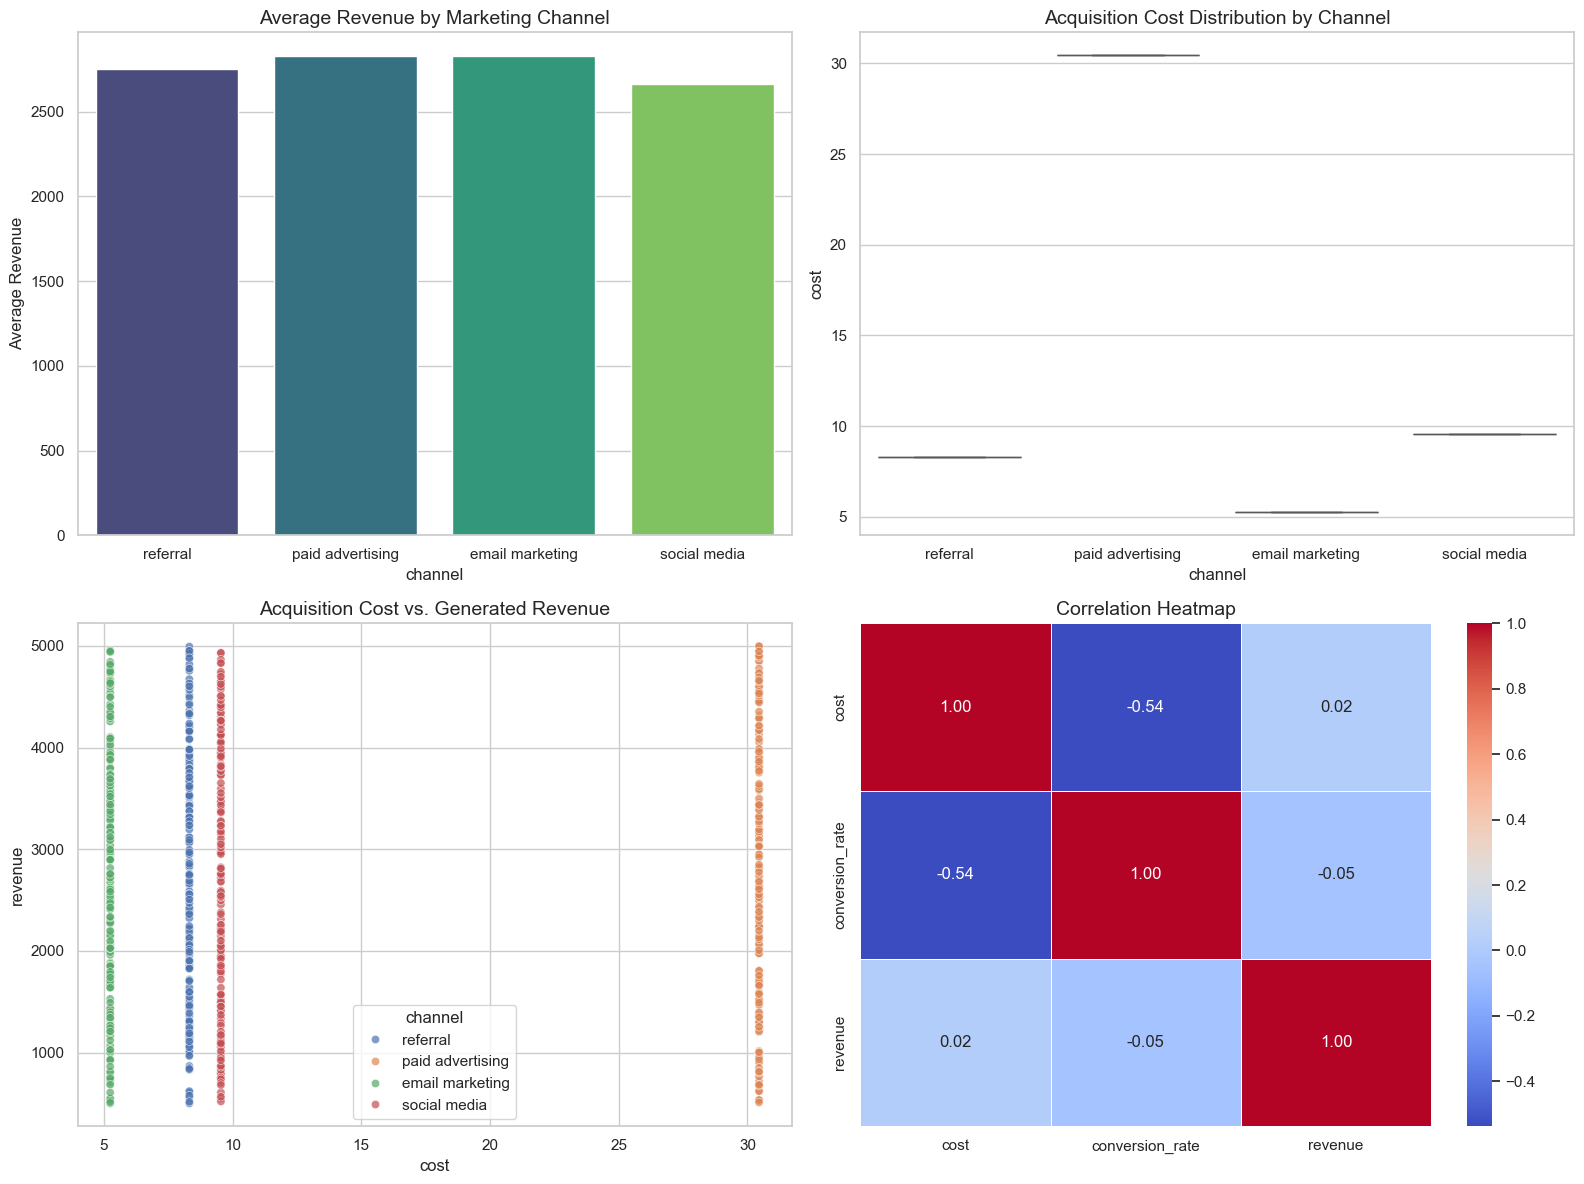

In [7]:
# Cell 4
print("--- Cleaned Statistical Summary ---")
display(df_cleaned.describe())

# Set up the visual canvas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

# 1. Bar Chart: Average Revenue by Marketing Channel
plt.subplot(2, 2, 1)
# Fixed: Changed ci=None to errorbar=None, and assigned x to hue
sns.barplot(data=df_cleaned, x='channel', y='revenue', errorbar=None, hue='channel', legend=False, palette='viridis')
plt.title('Average Revenue by Marketing Channel', fontsize=14)
plt.ylabel('Average Revenue')

# 2. Boxplot: Acquisition Cost by Channel
plt.subplot(2, 2, 2)
# Fixed: Assigned x to hue to satisfy the new seaborn standard
sns.boxplot(data=df_cleaned, x='channel', y='cost', hue='channel', legend=False, palette='Set2')
plt.title('Acquisition Cost Distribution by Channel', fontsize=14)

# 3. Scatter Plot: Cost vs Revenue
plt.subplot(2, 2, 3)
sns.scatterplot(data=df_cleaned, x='cost', y='revenue', hue='channel', alpha=0.7)
plt.title('Acquisition Cost vs. Generated Revenue', fontsize=14)

# 4. Heatmap: Correlation Matrix
plt.subplot(2, 2, 4)
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).drop(columns=['customer_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()